# 🧱 Part 05: From Transformer to Mini-GPT

> **Previous context**: In the last part you implemented Self-Attention, Multi-Head Attention, and a Transformer Block.
> **Goal for this part**: Follow the GPT-2 structure diagram, stack Blocks into a Mini-GPT that outputs logits, and compare our implementation with Karpathy's `nanoGPT` style.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time

import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)


## 1. Learning map

This part answers one question: **we already have a Transformer Block, how do we turn it into GPT?**

You can think of GPT as a pipeline:

```text
Token IDs
  -> token embedding + position embedding
  -> Transformer Block x N
  -> LayerNorm
  -> Linear
  -> logits: for each position, predict the next token
```

The point is not memorizing names. Watch the shapes:

```text
[batch, seq] -> [batch, seq, d_model] -> [batch, seq, vocab_size]
```


## 2. Reuse the Block

To make this notebook self-contained, we copy the three parts from the previous chapter.

You do not need to re-derive every line right now. Just remember their roles:

1. `MultiHeadAttention`: tokens can attend to each other, but cannot see the future.
2. `FeedForward`: each token passes through a small MLP.
3. `TransformerBlock`: chain Attention, FFN, Residual, and LayerNorm.


In [2]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head causal self-attention

    Args:
        d_model: input/output dimension
        num_heads: number of attention heads
    """

    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Q/K/V projections
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)

        # output projection
        self.W_O = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        """
        Input:  x shape = [batch, seq_len, d_model]
        Output:        = [batch, seq_len, d_model]
        """
        batch_size, seq_len, _ = x.shape

        # 1. project + split heads
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # 2. scores
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # 3. mask
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # 4. softmax
        weights = F.softmax(scores, dim=-1)

        # 5. weighted sum
        attn_output = weights @ V

        # 6. merge heads + output projection
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        return self.W_O(attn_output)


In [3]:
class FeedForward(nn.Module):
    """FFN: two linear layers, expand by 4x then project back."""

    def __init__(self, d_model, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


class TransformerBlock(nn.Module):
    """One Transformer decoder block: Attention + FFN, each with residual + LayerNorm."""

    def __init__(self, d_model, num_heads, d_ff=None):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attention(x, mask))  # Attention + residual + norm
        x = self.norm2(x + self.ffn(x))              # FFN + residual + norm
        return x


## 3. Implement MiniGPT by following the structure diagram

Now we assemble the full model.

Step 1: token IDs are integers, the network cannot consume them directly, so we do embedding lookup.

Step 2: the same token at position 1 vs position 10 can mean different things, so we add position information.

Step 3: pass through multiple Transformer Blocks.

Final: project hidden states to vocab size to get logits.


In [4]:
# Reuse the positional encoding from Part 03
def get_sinusoidal_encoding(seq_len, d_model):
    position = torch.arange(seq_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


class MiniGPT(nn.Module):
    """Mini GPT: Embedding -> N x TransformerBlock -> LayerNorm -> project to vocab logits."""

    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=4, max_seq_len=128):
        super().__init__()
        self.d_model = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        pe = get_sinusoidal_encoding(max_seq_len, d_model)
        self.register_buffer('pe', pe)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)  # project to vocab -> logits

    def forward(self, x):
        # x: [batch, seq_len] token IDs
        batch_size, seq_len = x.shape
        x = self.token_emb(x) + self.pe[:seq_len, :]          # embedding + position
        mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device))
        mask = mask.view(1, 1, seq_len, seq_len)
        for block in self.blocks:
            x = block(x, mask)
        x = self.ln_final(x)
        return self.lm_head(x)  # [batch, seq_len, vocab_size]


## 4. Run a full forward pass

The model is untrained, so the outputs are not smart.

But we do not care about correctness yet. We only care that data flows through the structure diagram correctly.


In [5]:
# Test MiniGPT
vocab_size = 30
model = MiniGPT(vocab_size=vocab_size, d_model=64, num_heads=4, num_layers=2)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params:,}, trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# forward: batch=2, seq_len=8
batch_input = torch.randint(0, vocab_size, (2, 8))
logits = model(batch_input)
print(f"\nInput: {batch_input.shape}  ->  output: {logits.shape}")
print(f"Output = [batch=2, seq=8, vocab={vocab_size}] -> logits for every token at every position")
print(f"logits[0, 7, :5]: {logits[0, 7, :5].tolist()}  <- sample 0, position 7, scores for next token")


Total params: 103,966, trainable: 103,966

Input: torch.Size([2, 8])  ->  output: torch.Size([2, 8, 30])
Output = [batch=2, seq=8, vocab=30] -> logits for every token at every position
logits[0, 7, :5]: [1.4079980850219727, -0.3056167960166931, -1.065438985824585, 0.11685330420732498, 0.531089186668396]  <- sample 0, position 7, scores for next token


In [6]:
# Follow the structure diagram once: print shapes at every step
vocab_size = 30
model = MiniGPT(vocab_size=vocab_size, d_model=32, num_heads=4, num_layers=2, max_seq_len=16)
idx = torch.randint(0, vocab_size, (2, 6))

with torch.no_grad():
    token_vec = model.token_emb(idx)
    pos_vec = model.pe[:idx.shape[1], :]
    x = token_vec + pos_vec
    print(f"1. token + position: {x.shape}")

    mask = torch.tril(torch.ones(idx.shape[1], idx.shape[1]))
    mask = mask.view(1, 1, idx.shape[1], idx.shape[1])

    for block_id, block in enumerate(model.blocks, start=1):
        x = block(x, mask)
        print(f"2.{block_id} after TransformerBlock: {x.shape}")

    x = model.ln_final(x)
    logits = model.lm_head(x)
    print(f"3. logits: {logits.shape}")

print("Key observation: hidden states stay d_model; only the final step projects to vocab_size.")


1. token + position: torch.Size([2, 6, 32])
2.1 after TransformerBlock: torch.Size([2, 6, 32])
2.2 after TransformerBlock: torch.Size([2, 6, 32])
3. logits: torch.Size([2, 6, 30])
Key observation: hidden states stay d_model; only the final step projects to vocab_size.


## 5. What are logits?

`logits` are the raw scores from the last layer.

If the vocab has 30 tokens, then at each position the model outputs 30 scores:

```text
logits[batch, position, token_id]
```

Higher score means the model believes this token is more suitable as the next token.

During training, Cross-Entropy pushes the correct token score up.
During generation, we apply softmax to logits, then sample or take argmax.


## 6. Karpathy's nanoGPT

Andrej Karpathy is an influential engineer and teacher in deep learning (Stanford CS231n, OpenAI, Tesla).

In this part we look only at `nanoGPT`.

`nanoGPT` is not a different conceptual model. It is a GPT-2 style PyTorch implementation:

1. The architecture is a GPT-2 decoder-only Transformer.
2. The code is short enough to read for learning.
3. The repo also supports `from_pretrained('gpt2')` for loading GPT-2 weights.

Below we run a tiny `nanoGPT` configuration.
It is randomly initialized and is used only to inspect structure, shapes, loss, and parameter counts.
We are not downloading GPT-2 pretrained weights here.


### Recommended reading order for `model.py`

When reading `nanoGPT/model.py`, follow this order:

```text
CausalSelfAttention   # self-attention with causal mask
MLP                   # per-token feed-forward network
Block                 # Attention + MLP + Residual + LayerNorm
GPT                   # assembly: embedding, blocks, ln_f, lm_head
GPT.forward           # the full dataflow
```

These names map directly to our hand-written version:

| Our version | nanoGPT code | Role |
|:---|:---|:---|
| `MultiHeadAttention` | `CausalSelfAttention` | multi-head causal self-attention |
| `FeedForward` | `MLP` | per-token transformation |
| `TransformerBlock` | `Block` | one decoder block |
| `MiniGPT` | `GPT` | full decoder-only model |
| `token_emb` | `transformer.wte` | token embedding table |
| `pe` / position | `transformer.wpe` | position embedding table |
| `lm_head` | `lm_head` | hidden state -> vocab logits |

Read `model.py` first, then training scripts. If the model skeleton is unclear, optimizer/checkpoints/logging will just become noise.


### The main line of `GPT.forward`

`GPT.forward` is the function worth reading first. It compresses the whole GPT dataflow into one line:

```text
idx
  -> wte(idx)                 # token embedding
  -> wpe(pos)                 # position embedding
  -> drop(tok_emb + pos_emb)
  -> for block in h           # many Transformer Blocks
  -> ln_f
  -> lm_head
  -> logits / loss
```

This is the same skeleton as our MiniGPT.

Engineering differences include:

1. `nanoGPT` uses one linear layer `c_attn` to compute Q/K/V together.
2. GPT-2 uses learned position embeddings `wpe`, not sinusoidal encoding.
3. `nanoGPT` uses weight tying: `wte.weight` shares with `lm_head.weight`.
4. Optimizer/checkpoint/sampling belong to training/inference engineering, not the main architecture line.


### Run nanoGPT tiny config

Below we run the local `nanoGPT/model.py`.

We do not download GPT-2 weights and do not run full training. We only run a tiny config forward pass and loss.

When reading the output, focus on two things:

1. Is `logits` shape `[batch, seq, vocab_size]`?
2. Is the loss of a randomly initialized model close to random-guess level?


In [7]:
# Run nanoGPT tiny config
from karpathy_models import NanoGPT, NanoGPTConfig

nano_config = NanoGPTConfig(
    block_size=16,
    vocab_size=64,
    n_layer=2,
    n_head=2,
    n_embd=32,
    dropout=0.0,
    bias=True,
)

torch.manual_seed(42)
nano_model = NanoGPT(nano_config)
nano_model.eval()

idx = torch.randint(0, nano_config.vocab_size, (2, 8))
targets = torch.randint(0, nano_config.vocab_size, (2, 8))

with torch.no_grad():
    nano_logits, nano_loss = nano_model(idx, targets)

print("=== nanoGPT tiny forward ===")
print(f"input shape:  {tuple(idx.shape)}")
print(f"logits shape: {tuple(nano_logits.shape)}")
print(f"loss:         {nano_loss.item():.4f}")
print(f"params:       {nano_model.get_num_params():,}")
print("Observation: logits is still [batch, seq, vocab_size].")


number of parameters: 0.03M
=== nanoGPT tiny forward ===
input shape:  (2, 8)
logits shape: (2, 8, 64)
loss:         4.1788
params:       27,520
Observation: logits is still [batch, seq, vocab_size].


## 7. Use line charts to probe nanoGPT behavior

Now we do more than one forward pass.

We run a few small experiments:

1. As the model gets deeper, how does parameter count change?
2. As sequence length grows, how does forward time change?
3. Is the loss of a randomly initialized model close to random guessing?

These experiments are not to prove the model "can generate" (it is untrained).
They are to observe shapes, parameter scaling, and runtime costs.


number of parameters: 0.01M
number of parameters: 0.03M
number of parameters: 0.05M
number of parameters: 0.08M
n_layer=1: params=14,816
n_layer=2: params=27,520
n_layer=4: params=52,928
n_layer=6: params=78,336
Observation: as you add layers, parameters in Attention and MLP scale roughly linearly.


<cell>:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


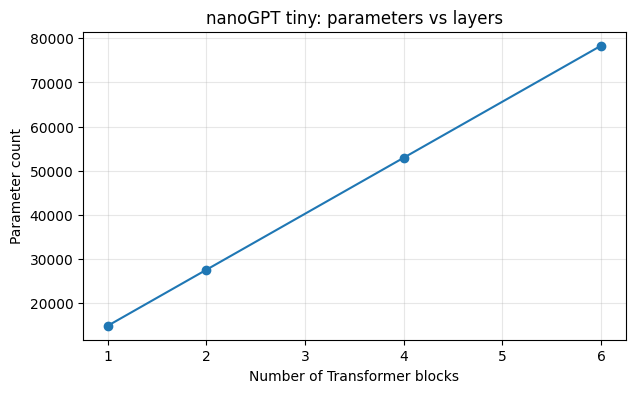

In [8]:
# Experiment 1: how does nanoGPT parameter count scale with depth?
layer_counts = [1, 2, 4, 6]
nano_param_counts = []

for n_layer in layer_counts:
    cfg = NanoGPTConfig(
        block_size=16,
        vocab_size=64,
        n_layer=n_layer,
        n_head=2,
        n_embd=32,
        dropout=0.0,
        bias=True,
    )
    model = NanoGPT(cfg)
    nano_param_counts.append(model.get_num_params())

plt.figure(figsize=(7, 4))
plt.plot(layer_counts, nano_param_counts, marker="o")
plt.xlabel("Number of Transformer blocks")
plt.ylabel("Parameter count")
plt.title("nanoGPT tiny: parameters vs layers")
plt.grid(True, alpha=0.3)
plt.show()

for n_layer, params in zip(layer_counts, nano_param_counts):
    print(f"n_layer={n_layer}: params={params:,}")

print("Observation: as you add layers, parameters in Attention and MLP scale roughly linearly.")


seq_len= 4: avg_forward_time=0.005289s
seq_len= 8: avg_forward_time=0.005419s
seq_len=12: avg_forward_time=0.003982s
seq_len=16: avg_forward_time=0.005236s
Observation: Self-Attention considers token-to-token interactions, so longer sequences are usually more expensive.


<cell>:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


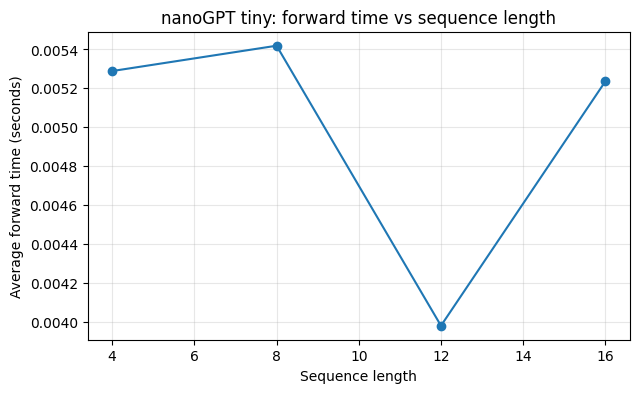

In [9]:
# Experiment 2: how does forward time change as sequence length increases?
# Note: single runs on CPU are noisy, so we average over repeats.
def benchmark_forward(model, seq_len, repeats=20):
    sample = torch.randint(0, nano_config.vocab_size, (2, seq_len))
    target = torch.randint(0, nano_config.vocab_size, (2, seq_len))
    with torch.no_grad():
        model(sample, target)  # warmup
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(repeats):
            model(sample, target)
    elapsed = time.perf_counter() - start
    return elapsed / repeats

seq_lengths = [4, 8, 12, 16]
forward_times = []
for seq_len_value in seq_lengths:
    forward_times.append(benchmark_forward(nano_model, seq_len_value))

plt.figure(figsize=(7, 4))
plt.plot(seq_lengths, forward_times, marker="o")
plt.xlabel("Sequence length")
plt.ylabel("Average forward time (seconds)")
plt.title("nanoGPT tiny: forward time vs sequence length")
plt.grid(True, alpha=0.3)
plt.show()

for seq_len_value, seconds in zip(seq_lengths, forward_times):
    print(f"seq_len={seq_len_value:2d}: avg_forward_time={seconds:.6f}s")

print("Observation: Self-Attention considers token-to-token interactions, so longer sequences are usually more expensive.")


nanoGPT loss:       4.1190
random guess loss:  4.1589
Observation: an untrained GPT has loss close to random guessing. This is normal.


<cell>:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


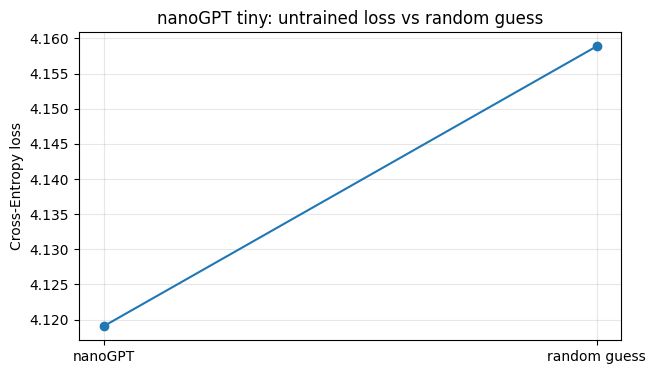

In [10]:
# Experiment 3: nanoGPT untrained loss vs random-guess level
# The model is untrained, so the loss should be close to log(vocab_size).
torch.manual_seed(123)
compare_idx = torch.randint(0, 64, (4, 12))
compare_targets = torch.randint(0, 64, (4, 12))

with torch.no_grad():
    compare_logits, compare_loss = nano_model(compare_idx, compare_targets)

random_guess_loss = math.log(64)
losses = [compare_loss.item(), random_guess_loss]
names = ["nanoGPT", "random guess"]

plt.figure(figsize=(7, 4))
plt.plot(names, losses, marker="o")
plt.ylabel("Cross-Entropy loss")
plt.title("nanoGPT tiny: untrained loss vs random guess")
plt.grid(True, alpha=0.3)
plt.show()

print(f"nanoGPT loss:       {compare_loss.item():.4f}")
print(f"random guess loss:  {random_guess_loss:.4f}")
print("Observation: an untrained GPT has loss close to random guessing. This is normal.")


## 8. After the comparison, revisit MiniGPT

Now place our teaching version and `nanoGPT` side by side:

| Teaching version | nanoGPT | Meaning |
|:---|:---|:---|
| `MiniGPT` | `GPT` | full model |
| `TransformerBlock` | `Block` | one decoder block |
| `MultiHeadAttention` | `CausalSelfAttention` | causal self-attention |
| `FeedForward` | `MLP` | per-token nonlinearity |
| `token_emb` | `transformer.wte` | token embedding |
| `pe` / position | `transformer.wpe` | position embedding |
| `lm_head` | `lm_head` | hidden -> vocab logits |

When reading real-world code, follow `GPT.forward` first. Once that main line is clear, training script details will not confuse you.


## 9. Special tokens

Mini-GPT outputs logits, but it also needs some boundary/control symbols.

For example: where the sequence starts/ends, which positions are padding, and where a reasoning scratchpad begins/ends.

```text
<BOS>       begin of sequence
<EOS>       end of sequence
<PAD>       padding positions
<think>     start of a thinking region
</think>    end of a thinking region
```

`<think>` does not automatically make the model smarter. It is only a symbol.

For the model to use it, the training data must repeatedly include this format.


In [11]:
# Demo: add new special tokens to Mini-GPT's vocabulary
base_vocab = {
    "user": 0,
    "assistant": 1,
    "answer": 2,
    "357": 3,
    "289": 4,
    "103173": 5,
}

special_tokens = ["<BOS>", "<EOS>", "<PAD>", "<think>", "</think>"]

vocab = base_vocab.copy()
for token in special_tokens:
    if token not in vocab:
        vocab[token] = len(vocab)

print("New special token IDs:")
for token in special_tokens:
    print(f"  {token:8s} -> {vocab[token]}")

print()
print("Key observation: <think> and </think> now have their own IDs,")
print("so the model can treat them as boundary/control symbols rather than ordinary text pieces.")


New special token IDs:
  <BOS>    -> 6
  <EOS>    -> 7
  <PAD>    -> 8
  <think>  -> 9
  </think> -> 10

Key observation: <think> and </think> now have their own IDs,
so the model can treat them as boundary/control symbols rather than ordinary text pieces.


In [12]:
# Demo: what a training sample with <think> might look like
sample_tokens = [
    "<BOS>",
    "user",
    "357",
    "289",
    "assistant",
    "<think>",
    "357",
    "289",
    "103173",
    "</think>",
    "answer",
    "103173",
    "<EOS>",
]

sample_ids = [vocab[token] for token in sample_tokens]

print("Training sample tokens:")
print(sample_tokens)
print()
print("Training sample IDs:")
print(sample_ids)
print()
print("Key observation: only when training data repeatedly contains such formats does the model learn when to start thinking and when to stop.")


Training sample tokens:
['<BOS>', 'user', '357', '289', 'assistant', '<think>', '357', '289', '103173', '</think>', 'answer', '103173', '<EOS>']

Training sample IDs:
[6, 0, 3, 4, 1, 9, 3, 4, 5, 10, 2, 5, 7]

Key observation: only when training data repeatedly contains such formats does the model learn when to start thinking and when to stop.


After adding special tokens, the vocabulary becomes larger.

Once the vocab grows, the embedding table must also grow, because each token needs its own vector.


In [13]:
# Small matrix demo: why the embedding table must expand after adding new tokens
old_vocab_size = len(base_vocab)
new_vocab_size = len(vocab)
d_model = 8

torch.manual_seed(42)
old_embedding = nn.Embedding(old_vocab_size, d_model)
new_embedding = nn.Embedding(new_vocab_size, d_model)

# Copy old token vectors. New token rows stay randomly initialized and will be updated during training.
with torch.no_grad():
    new_embedding.weight[:old_vocab_size] = old_embedding.weight

print(f"Old vocab size: {old_vocab_size}")
print(f"New vocab size: {new_vocab_size}")
print(f"Embedding shape: {tuple(new_embedding.weight.shape)}")
print()
print("Key observation: after adding 5 special tokens, the embedding table also gains 5 new rows.")
print("Those new rows only become meaningful through further training.")


Old vocab size: 6
New vocab size: 11
Embedding shape: (11, 8)

Key observation: after adding 5 special tokens, the embedding table also gains 5 new rows.
Those new rows only become meaningful through further training.


## Summary

Make sure you understand:

1. GPT = Embedding + Position + multiple Transformer Blocks + output projection
2. The hidden state shape usually stays `[batch, seq, d_model]` through the middle
3. Only the final `lm_head` changes the last dimension to `vocab_size`
4. Logits are raw scores for the next-token prediction
5. Karpathy/nanoGPT uses more engineering names, but the skeleton matches our hand-written version
6. Special tokens need their own IDs, and embedding must expand

Next: training. How is the loss computed, and how does the model move from random guessing to meaningful continuation?


---

## Exercises: Mini-GPT

This exercise checks that you understand temperature, a common knob in generation.

> **About using AI**: it is fine to ask for intuition about how temperature affects a probability distribution, but write the logit-scaling line yourself.


### Exercise 3: modern practice - temperature scaling for logits

During generation, temperature controls randomness. Smaller temperature makes the distribution sharper; larger temperature makes it flatter.

**Hint**: a common pattern is `scaled_logits = logits / temperature`.


In [ ]:
# Exercise 3: temperature scaling for logits
import torch

logits = torch.tensor([1.0, 2.0, 3.0])
temperature = 0.5

# TODO: scale logits by temperature
scaled_logits = """Scale `logits` here."""

assert not isinstance(scaled_logits, str), "Please replace the placeholder inside the triple quotes."
assert torch.allclose(scaled_logits, torch.tensor([2.0, 4.0, 6.0])), scaled_logits
print("OK Exercise 3 passed: temperature < 1 increases logit gaps, making the distribution sharper")
